In [1]:
# ============================================
# SALES PREDICTION USING PYTHON
# Étape 1 : Chargement des données
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset
df = pd.read_csv('advertising.csv')

# Aperçu des données
print("✅ Dataset chargé avec succès !")
print(f"📊 Taille : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("\n--- Aperçu des données ---")
df.head(10)

✅ Dataset chargé avec succès !
📊 Taille : 200 lignes, 5 colonnes

--- Aperçu des données ---


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [2]:
# ============================================
# Étape 2 : Exploration des données
# ============================================

# Supprimer la colonne inutile
df.drop('Unnamed: 0', axis=1, inplace=True)

print("=" * 50)
print("📋 INFORMATIONS GÉNÉRALES")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("📊 STATISTIQUES DE BASE")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print("❓ VALEURS MANQUANTES")
print("=" * 50)
print(df.isnull().sum())

📋 INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

📊 STATISTIQUES DE BASE
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000

❓ VALEURS MANQUANTES
TV           0
Radio        0
Newspaper    0
Sales        0

C:\Users\hp\AppData\Local\Temp\ipykernel_18748\645238906.py:14: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


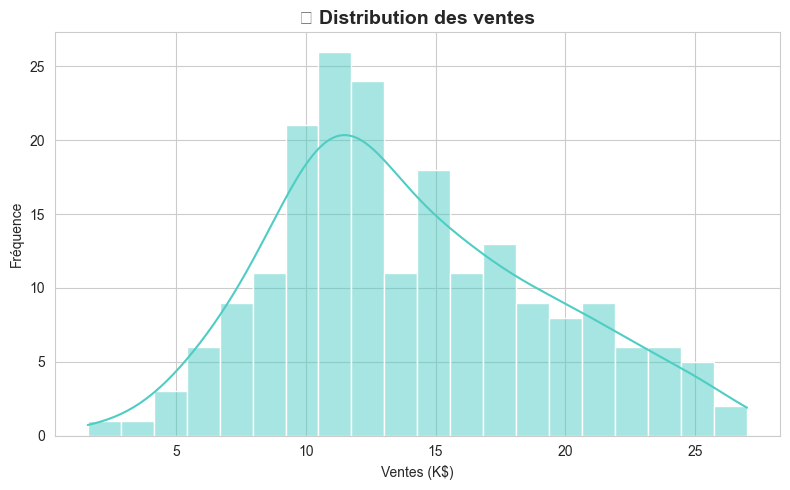

In [3]:
# ============================================
# Étape 3 : Visualisation
# ============================================

sns.set_style("whitegrid")

# --- Graphique 1 : Distribution des ventes ---
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], bins=20, color='#4ECDC4', kde=True)
plt.title('💰 Distribution des ventes', 
          fontsize=14, fontweight='bold')
plt.xlabel('Ventes (K$)')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_18748\4038098496.py:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


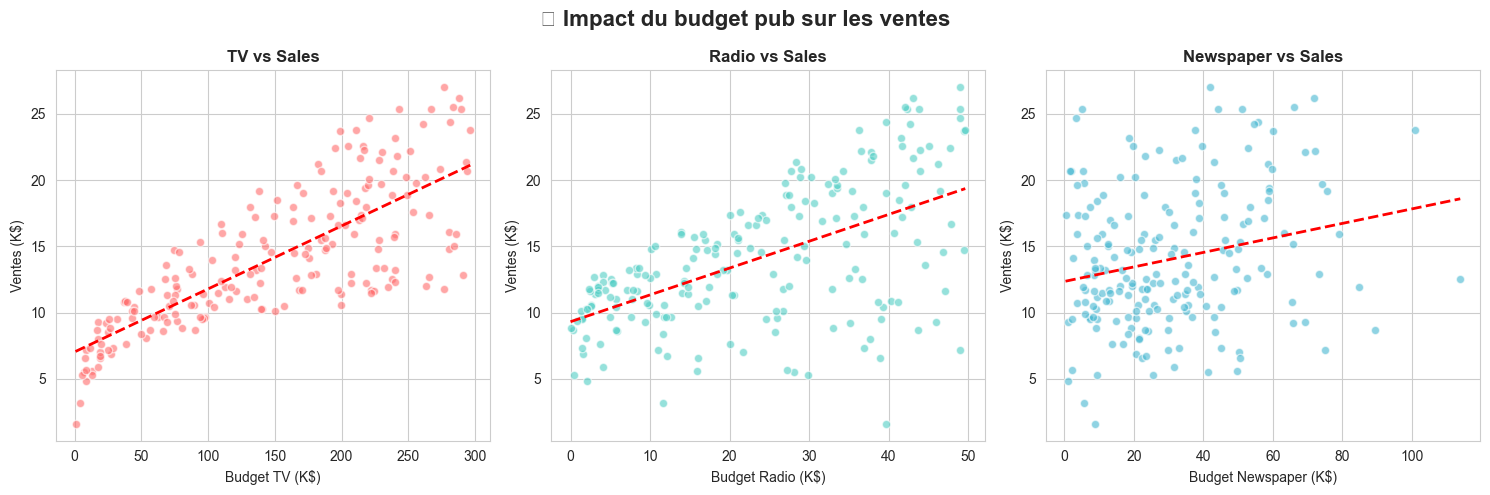

In [4]:
# --- Graphique 2 : Budget pub vs Ventes ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('📊 Impact du budget pub sur les ventes',
             fontsize=16, fontweight='bold')

canaux = ['TV', 'Radio', 'Newspaper']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, (canal, color) in enumerate(zip(canaux, colors)):
    axes[i].scatter(df[canal], df['Sales'], 
                   color=color, alpha=0.6, edgecolor='white')
    # Ligne de tendance
    z = np.polyfit(df[canal], df['Sales'], 1)
    p = np.poly1d(z)
    axes[i].plot(sorted(df[canal]), p(sorted(df[canal])), 
                "r--", linewidth=2)
    axes[i].set_title(f'{canal} vs Sales', fontweight='bold')
    axes[i].set_xlabel(f'Budget {canal} (K$)')
    axes[i].set_ylabel('Ventes (K$)')

plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_18748\2036972563.py:7: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


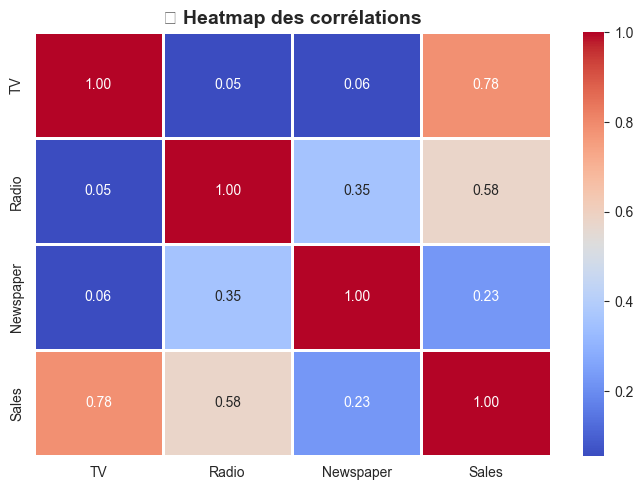

In [5]:
# --- Graphique 3 : Heatmap corrélations ---
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', linewidths=2, linecolor='white')
plt.title('🔥 Heatmap des corrélations',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ============================================
# Étape 4 : Préparation des données
# ============================================

from sklearn.model_selection import train_test_split

# Features et target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Données préparées !")
print(f"📚 Entraînement : {X_train.shape[0]} entrées")
print(f"🧪 Test         : {X_test.shape[0]} entrées")

✅ Données préparées !
📚 Entraînement : 160 entrées
🧪 Test         : 40 entrées


In [7]:
# ============================================
# Étape 5 : Entraînement des modèles
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

modeles = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

resultats = {}

print("🚀 Entraînement des modèles...\n")
print(f"{'Modèle':<20} {'R² Score':>10} {'MAE':>10} {'RMSE':>10}")
print("-" * 55)

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    resultats[nom] = {
        'modele': modele, 'r2': r2,
        'mae': mae, 'rmse': rmse, 'y_pred': y_pred
    }
    print(f"{nom:<20} {r2:>10.4f} {mae:>10.4f} {rmse:>10.4f}")

meilleur = max(resultats, key=lambda x: resultats[x]['r2'])
print(f"\n🏆 Meilleur modèle : {meilleur}")
print(f"   R² Score : {resultats[meilleur]['r2']*100:.2f}%")

🚀 Entraînement des modèles...

Modèle                 R² Score        MAE       RMSE
-------------------------------------------------------
Linear Regression        0.8994     1.4608     1.7816
Random Forest            0.9813     0.6201     0.7686
Gradient Boosting        0.9831     0.6187     0.7298

🏆 Meilleur modèle : Gradient Boosting
   R² Score : 98.31%


C:\Users\hp\AppData\Local\Temp\ipykernel_18748\810767802.py:19: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


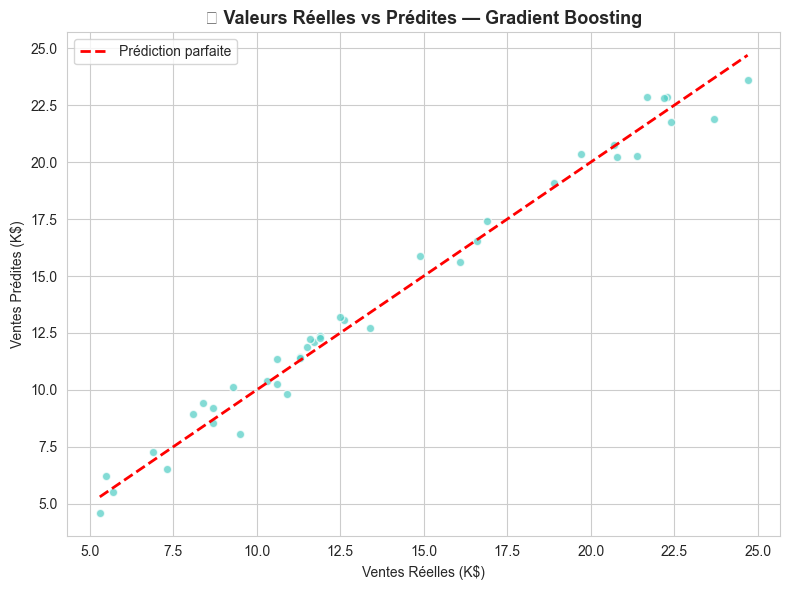

In [8]:
# ============================================
# Étape 6 : Visualisation des résultats
# ============================================

# --- Réel vs Prédit ---
y_pred_best = resultats['Gradient Boosting']['y_pred']

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, 
            color='#4ECDC4', alpha=0.7, edgecolor='white')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Prédiction parfaite')
plt.title('🎯 Valeurs Réelles vs Prédites — Gradient Boosting',
          fontsize=13, fontweight='bold')
plt.xlabel('Ventes Réelles (K$)')
plt.ylabel('Ventes Prédites (K$)')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_18748\1377276178.py:21: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


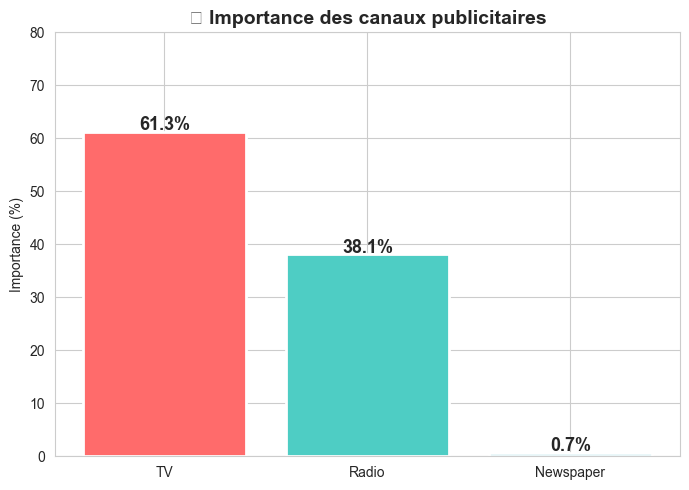

In [9]:
# --- Feature Importance ---
modele_final = resultats['Gradient Boosting']['modele']
importances = modele_final.feature_importances_
features = ['TV', 'Radio', 'Newspaper']

plt.figure(figsize=(7, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(features, importances * 100,
               color=colors, edgecolor='white', linewidth=2)

for bar, imp in zip(bars, importances):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{imp*100:.1f}%', ha='center',
             fontsize=13, fontweight='bold')

plt.title('🔑 Importance des canaux publicitaires',
          fontsize=14, fontweight='bold')
plt.ylabel('Importance (%)')
plt.ylim(0, 80)
plt.tight_layout()
plt.show()

In [10]:
# ============================================
# Étape 7 : Prédiction sur nouveaux budgets
# ============================================

def predire_ventes(tv, radio, newspaper):
    features = np.array([[tv, radio, newspaper]])
    ventes = modele_final.predict(features)[0]
    
    print("=" * 45)
    print("📈 RÉSULTAT DE LA PRÉDICTION")
    print("=" * 45)
    print(f"📺 Budget TV        : {tv} K$")
    print(f"📻 Budget Radio     : {radio} K$")
    print(f"📰 Budget Newspaper : {newspaper} K$")
    print(f"💰 Budget Total     : {tv+radio+newspaper} K$")
    print("-" * 45)
    print(f"🎯 VENTES PRÉDITES  : {ventes:.2f} K$")
    print("=" * 45)

print("📊 TEST 1 — Gros budget TV")
predire_ventes(tv=230, radio=37, newspaper=69)

print("\n📊 TEST 2 — Budget équilibré")
predire_ventes(tv=100, radio=20, newspaper=10)

print("\n📊 TEST 3 — Petit budget")
predire_ventes(tv=50, radio=10, newspaper=5)

📊 TEST 1 — Gros budget TV
📈 RÉSULTAT DE LA PRÉDICTION
📺 Budget TV        : 230 K$
📻 Budget Radio     : 37 K$
📰 Budget Newspaper : 69 K$
💰 Budget Total     : 336 K$
---------------------------------------------
🎯 VENTES PRÉDITES  : 21.57 K$

📊 TEST 2 — Budget équilibré
📈 RÉSULTAT DE LA PRÉDICTION
📺 Budget TV        : 100 K$
📻 Budget Radio     : 20 K$
📰 Budget Newspaper : 10 K$
💰 Budget Total     : 130 K$
---------------------------------------------
🎯 VENTES PRÉDITES  : 11.85 K$

📊 TEST 3 — Petit budget
📈 RÉSULTAT DE LA PRÉDICTION
📺 Budget TV        : 50 K$
📻 Budget Radio     : 10 K$
📰 Budget Newspaper : 5 K$
💰 Budget Total     : 65 K$
---------------------------------------------
🎯 VENTES PRÉDITES  : 9.56 K$


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
